In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters
ticker = "AAPL"
S0 = 255.78          # Current AAPL Price
K = 260.00           # Strike Price
T = 1.0              # Time to expiration (1 year)
n_steps = 252        # Trading days in a year
n_sims = 10000       # Number of "Futures" to simulate

In [ ]:
mu = 0.14            # 14% Estimated Annualized Drift as per 5 year average annual return approximation
sigma = 0.28         # 28% Estimated Annualized Volatility
dt = T / n_steps

In [4]:
# Monte Carlo Simulation using the Wiener Process
# We generate all random shocks (Z) at once for efficiency

Z = np.random.standard_normal((n_steps, n_sims))

In [5]:
# Calculate daily price changes using Geometric Brownian Motion
daily_drift = (mu - 0.5 * sigma**2) * dt
daily_shocks = sigma * np.sqrt(dt) * Z

In [6]:
# Initialize the price paths array
price_paths = np.zeros((n_steps + 1, n_sims))
price_paths[0] = S0

In [7]:
# Build the paths: Previous Price * e^(random daily change)
for t in range(1, n_steps + 1):
    price_paths[t] = price_paths[t-1] * np.exp(daily_drift + daily_shocks[t-1])

In [9]:
#  Option value
final_prices = price_paths[-1]
payoffs = np.maximum(final_prices - K, 0)
risk_free_rate = 0.04  # 4% discounting rate
option_price = np.mean(payoffs) * np.exp(-risk_free_rate * T)

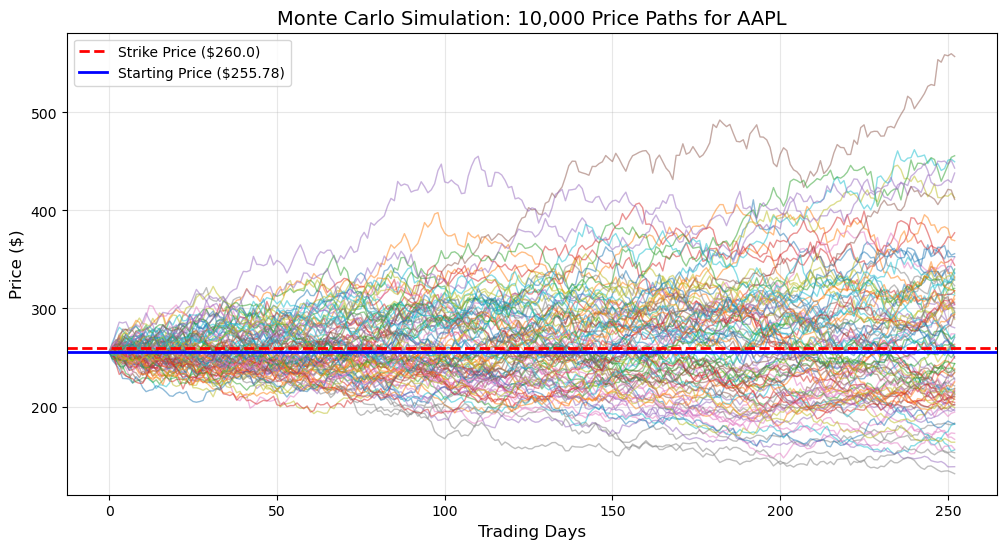

Estimated Call Option Value: $45.66
Minimum Simulated Price: $93.85
Minimum Simulated Price: $825.92


In [11]:
# Plotting the Results
plt.figure(figsize=(12, 6))

# Plot the first 100 paths for clarity
plt.plot(price_paths[:, :100], lw=1, alpha=0.5)

# Add reference lines for context
plt.axhline(K, color='red', linestyle='--', linewidth=2, label=f'Strike Price (${K})')
plt.axhline(S0, color='blue', linestyle='-', linewidth=2, label=f'Starting Price (${S0})')

plt.title(f'Monte Carlo Simulation: 10,000 Price Paths for {ticker}', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated Call Option Value: ${option_price:.2f}")
print(f"Minimum Simulated Price: ${np.min(price_paths):.2f}")
print(f"Minimum Simulated Price: ${np.max(price_paths):.2f}")